In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Load data
df = pd.read_csv('C:\\Users\\ANKIT\\OneDrive\\Desktop\\INFOBYTE\\intrn\\data\\car data.csv')

In [17]:
# Feature Engineering
from datetime import datetime
df['Car_Age'] = datetime.now().year - df['Year']
X = df.drop(['Selling_Price', 'Year'], axis=1)
y = df['Selling_Price']

In [18]:
# Identify column types
numerical = X.select_dtypes(include=np.number).columns.tolist()
categorical = X.select_dtypes(include='object').columns.tolist()

In [19]:
# Preprocessing
numeric_transform = Pipeline([('scaler', StandardScaler())])
categoric_transform = Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([
    ('num', numeric_transform, numerical),
    ('cat', categoric_transform, categorical)
])

In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Model pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train and predict
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [22]:
# Evaluation
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

MAE: 0.62
RMSE: 0.91
R²: 0.9639


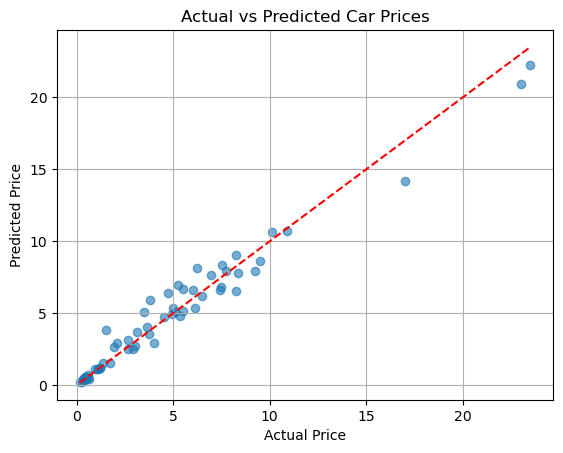

In [23]:
# Visualize predictions
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()